In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries loaded!")

✓ All libraries loaded!


In [2]:
sales_df = pd.read_csv("C:\\Users\\Lenovo\\Downloads\\Advertising (1).csv")

print("Dataset loaded successfully!")
print(f"Dataset Shape: {sales_df.shape}")
print("\nFirst 10 rows:")
print(sales_df.head(10))
print("\nColumn Names:")
print(sales_df.columns.tolist())
print("\nData Types:")
print(sales_df.dtypes)

Dataset loaded successfully!
Dataset Shape: (200, 5)

First 10 rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
5           6    8.7   48.9       75.0    7.2
6           7   57.5   32.8       23.5   11.8
7           8  120.2   19.6       11.6   13.2
8           9    8.6    2.1        1.0    4.8
9          10  199.8    2.6       21.2   10.6

Column Names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Data Types:
Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object


In [3]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print(sales_df.info())

print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)
print(sales_df.describe())

print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
missing_values = sales_df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n" + "="*70)
print("UNIQUE VALUES PER COLUMN")
print("="*70)
for col in sales_df.columns:
    unique_count = sales_df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count <= 20 and unique_count > 0:
        print(f"  Sample values: {sales_df[col].unique()[:5]}")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

STATISTICAL SUMMARY
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.1000

In [4]:
sales_column = None
sales_keywords = ['sales', 'revenue', 'amount', 'sold', 'quantity']

for col in sales_df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in sales_keywords):
        if sales_df[col].dtype in ['float64', 'int64']:
            sales_column = col
            print(f"✓ Sales column detected: {col}")
            break

if sales_column is None:
    print("⚠ Could not detect sales column. Showing all numeric columns:")
    print(sales_df.select_dtypes(include=[np.number]).columns.tolist())
    print("Please specify the sales_column manually above.")
else:
    print(f"\nSales Statistics:")
    print(sales_df[sales_column].describe())

numerical_cols = sales_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = sales_df.select_dtypes(include=['object']).columns.tolist()

if sales_column in numerical_cols:
    numerical_cols.remove(sales_column)

budget_cols = [col for col in numerical_cols if any(keyword in col.lower() 
               for keyword in ['budget', 'spend', 'advertising', 'ad', 'tv', 'radio', 'newspaper', 'social', 'online'])]

print(f"\n✓ Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"✓ Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"✓ Budget/Advertising Columns ({len(budget_cols)}): {budget_cols}")

✓ Sales column detected: Sales

Sales Statistics:
count    200.000000
mean      14.022500
std        5.217457
min        1.600000
25%       10.375000
50%       12.900000
75%       17.400000
max       27.000000
Name: Sales, dtype: float64

✓ Numerical Features (4): ['Unnamed: 0', 'TV', 'Radio', 'Newspaper']
✓ Categorical Features (0): []
✓ Budget/Advertising Columns (3): ['TV', 'Radio', 'Newspaper']


In [5]:
df_clean = sales_df.copy()

print("="*70)
print("DATA CLEANING")
print("="*70)

missing_before = df_clean.isnull().sum().sum()
print(f"Total missing values before cleaning: {missing_before}")

if missing_before > 0:
    for col in numerical_cols:
        if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"  Filled {col} with median: {median_val}")
    
    for col in categorical_cols:
        if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"  Filled {col} with mode: {mode_val}")
    
    if df_clean[sales_column].isnull().sum() > 0:
        rows_before = len(df_clean)
        df_clean = df_clean.dropna(subset=[sales_column])
        print(f"  Dropped {rows_before - len(df_clean)} rows with missing sales")

print(f"\nTotal missing values after cleaning: {df_clean.isnull().sum().sum()}")

duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    print(f"\nRemoving {duplicates} duplicate rows...")
    df_clean = df_clean.drop_duplicates()

Q1 = df_clean[sales_column].quantile(0.01)
Q3 = df_clean[sales_column].quantile(0.99)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_before = len(df_clean)
df_clean = df_clean[(df_clean[sales_column] >= lower_bound) & 
                    (df_clean[sales_column] <= upper_bound)]
outliers_removed = outliers_before - len(df_clean)

if outliers_removed > 0:
    print(f"\nRemoved {outliers_removed} sales outliers")

print(f"\n✓ Clean dataset shape: {df_clean.shape}")
print(f"Sales range: ${df_clean[sales_column].min():,.2f} - ${df_clean[sales_column].max():,.2f}")

DATA CLEANING
Total missing values before cleaning: 0

Total missing values after cleaning: 0

✓ Clean dataset shape: (200, 5)
Sales range: $1.60 - $27.00


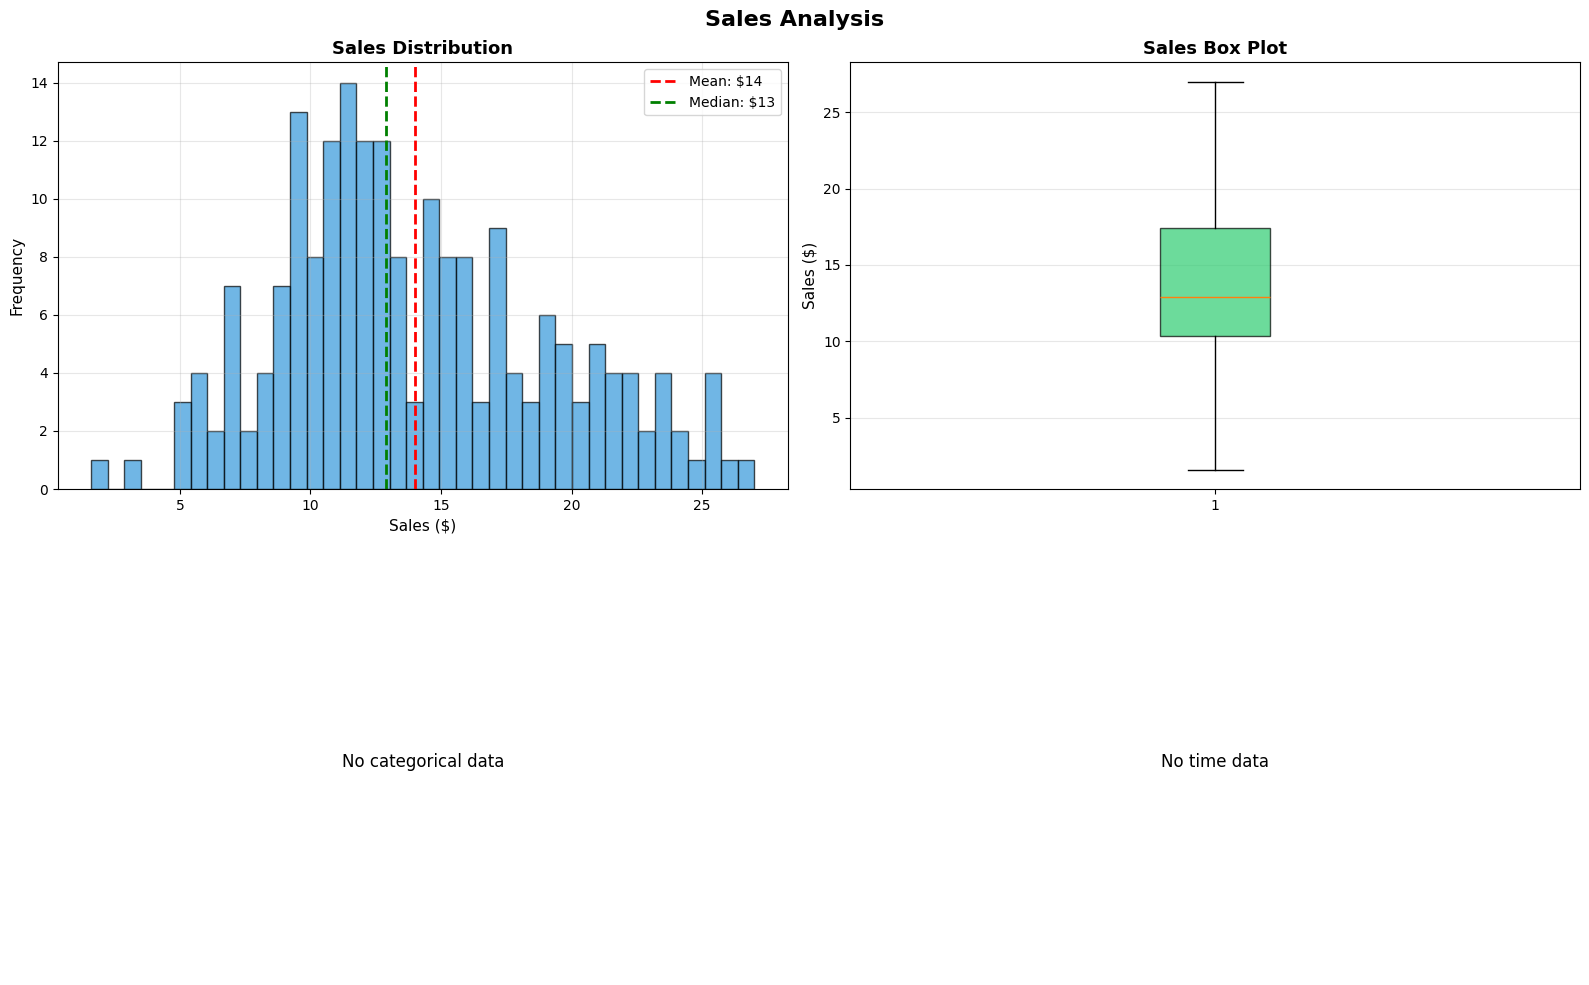

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Sales Analysis', fontsize=16, fontweight='bold')

axes[0, 0].hist(df_clean[sales_column], bins=40, color='#3498db', 
                edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_clean[sales_column].mean(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Mean: ${df_clean[sales_column].mean():,.0f}')
axes[0, 0].axvline(df_clean[sales_column].median(), color='green', 
                   linestyle='--', linewidth=2, 
                   label=f'Median: ${df_clean[sales_column].median():,.0f}')
axes[0, 0].set_title('Sales Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Sales ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

bp = axes[0, 1].boxplot(df_clean[sales_column], vert=True, patch_artist=True,
                        boxprops=dict(facecolor='#2ecc71', alpha=0.7))
axes[0, 1].set_title('Sales Box Plot', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Sales ($)', fontsize=11)
axes[0, 1].grid(alpha=0.3, axis='y')

if len(categorical_cols) > 0:
    cat_col = categorical_cols[0]
    
    top_categories = df_clean[cat_col].value_counts().head(10).index
    filtered_data = df_clean[df_clean[cat_col].isin(top_categories)]
    
    category_sales = filtered_data.groupby(cat_col)[sales_column].mean().sort_values(ascending=False)
    
    axes[1, 0].barh(category_sales.index, category_sales.values, 
                    color='#e74c3c', edgecolor='black')
    axes[1, 0].set_title(f'Average Sales by {cat_col}', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Average Sales ($)', fontsize=11)
    axes[1, 0].grid(alpha=0.3, axis='x')
else:
    axes[1, 0].text(0.5, 0.5, 'No categorical data', 
                    ha='center', va='center', fontsize=12)
    axes[1, 0].axis('off')

time_cols = [col for col in df_clean.columns if any(keyword in col.lower() 
             for keyword in ['date', 'time', 'year', 'month', 'day', 'period'])]

if len(time_cols) > 0:
    time_col = time_cols[0]
    
    try:
        time_sales = df_clean.groupby(time_col)[sales_column].mean().sort_index()
        
        axes[1, 1].plot(time_sales.index, time_sales.values, 
                        marker='o', linewidth=2.5, markersize=6, color='#9b59b6')
        axes[1, 1].fill_between(range(len(time_sales)), time_sales.values, 
                                alpha=0.3, color='#9b59b6')
        axes[1, 1].set_title(f'Sales Trend by {time_col}', fontsize=13, fontweight='bold')
        axes[1, 1].set_xlabel(time_col, fontsize=11)
        axes[1, 1].set_ylabel('Average Sales ($)', fontsize=11)
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(alpha=0.3)
    except:
        axes[1, 1].text(0.5, 0.5, 'Could not plot time trend', 
                        ha='center', va='center', fontsize=12)
        axes[1, 1].axis('off')
else:
    axes[1, 1].text(0.5, 0.5, 'No time data', 
                    ha='center', va='center', fontsize=12)
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

ADVERTISING BUDGET ANALYSIS

TV:
  Mean: $147.04
  Median: $149.75
  Min: $0.70
  Max: $296.40

Radio:
  Mean: $23.26
  Median: $22.90
  Min: $0.00
  Max: $49.60

Newspaper:
  Mean: $30.55
  Median: $25.75
  Min: $0.30
  Max: $114.00


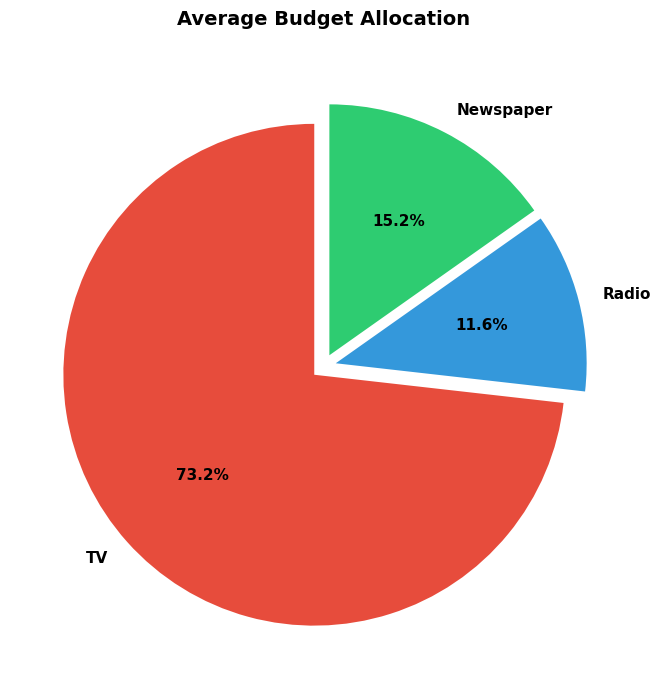

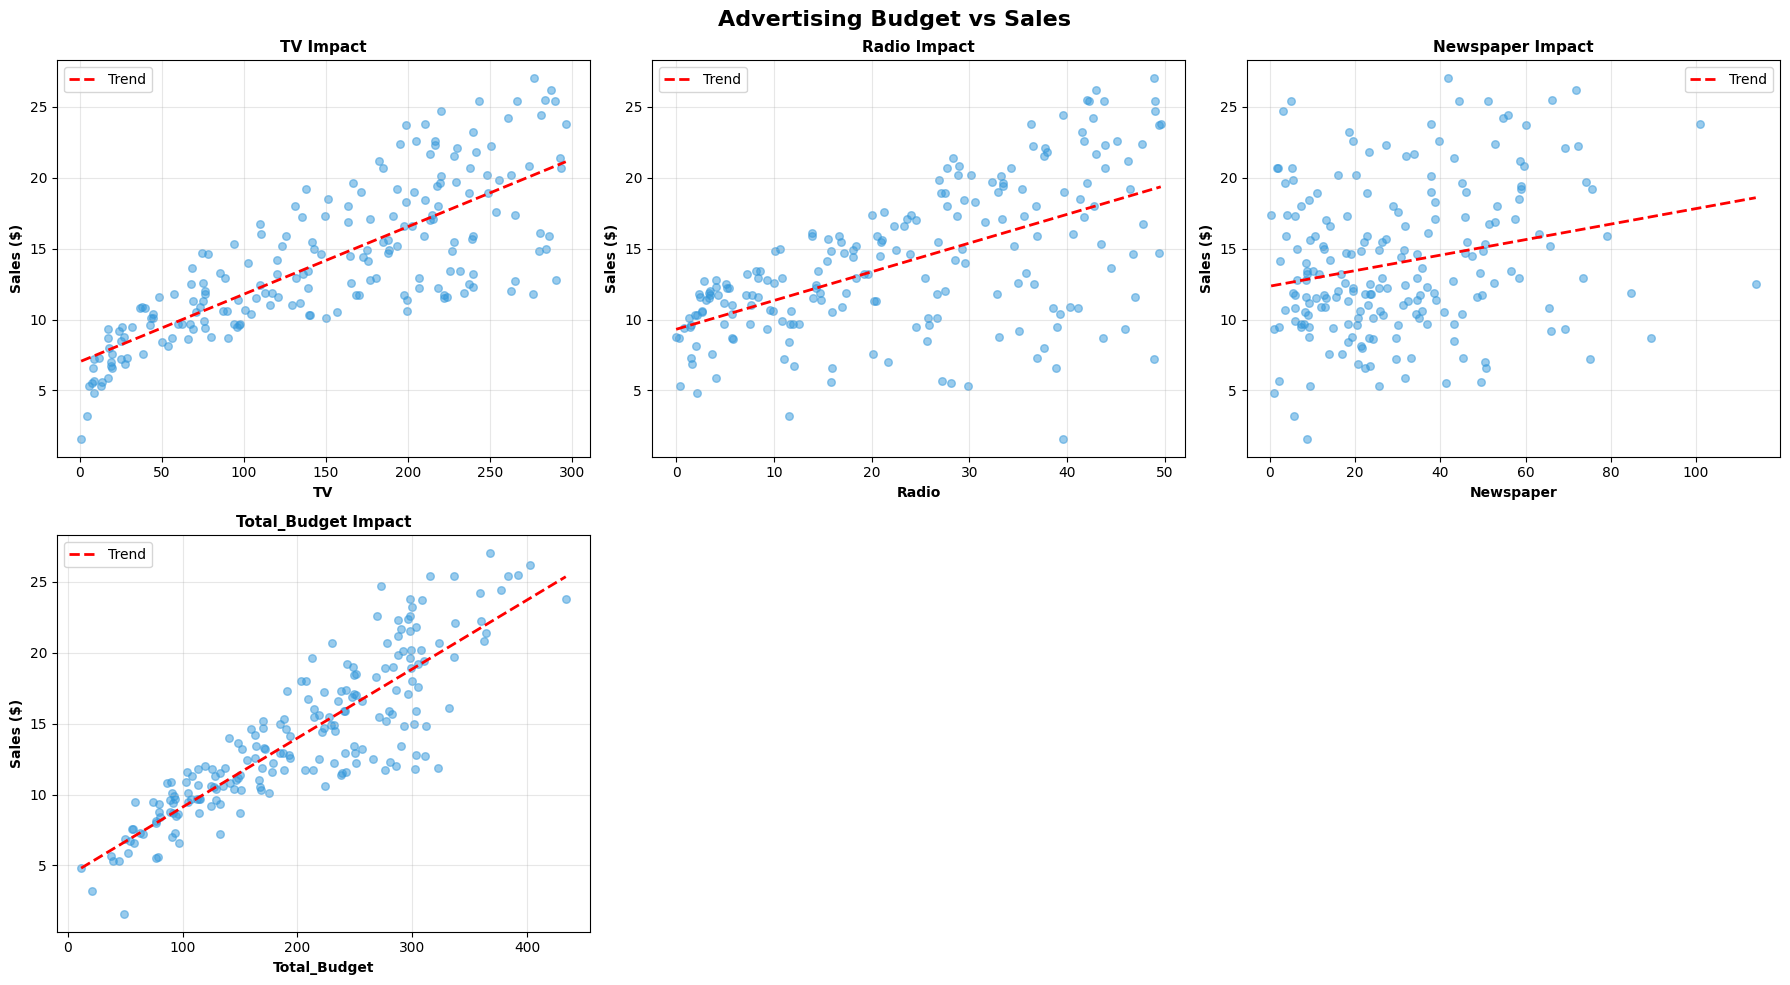

In [7]:
if len(budget_cols) > 0:
    print("="*70)
    print("ADVERTISING BUDGET ANALYSIS")
    print("="*70)
    
    if len(budget_cols) > 1:
        df_clean['Total_Budget'] = df_clean[budget_cols].sum(axis=1)
        budget_cols_with_total = budget_cols + ['Total_Budget']
    else:
        budget_cols_with_total = budget_cols
    
    for col in budget_cols:
        print(f"\n{col}:")
        print(f"  Mean: ${df_clean[col].mean():,.2f}")
        print(f"  Median: ${df_clean[col].median():,.2f}")
        print(f"  Min: ${df_clean[col].min():,.2f}")
        print(f"  Max: ${df_clean[col].max():,.2f}")
    
    if len(budget_cols) > 1:
        avg_budgets = df_clean[budget_cols].mean()
        
        plt.figure(figsize=(10, 7))
        colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
        plt.pie(avg_budgets.values, labels=avg_budgets.index, autopct='%1.1f%%',
               startangle=90, colors=colors[:len(budget_cols)], 
               textprops={'fontsize': 11, 'fontweight': 'bold'},
               explode=[0.05]*len(budget_cols))
        plt.title('Average Budget Allocation', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
    
    n_budgets = min(6, len(budget_cols_with_total))
    n_cols = 3
    n_rows = (n_budgets + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    fig.suptitle('Advertising Budget vs Sales', fontsize=16, fontweight='bold')
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx in range(n_budgets):
        row, col = idx // n_cols, idx % n_cols
        budget_col = budget_cols_with_total[idx]
        
        axes[row, col].scatter(df_clean[budget_col], df_clean[sales_column], 
                              alpha=0.5, s=30, color='#3498db')
        
        z = np.polyfit(df_clean[budget_col], df_clean[sales_column], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(df_clean[budget_col].min(), df_clean[budget_col].max(), 100)
        axes[row, col].plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend')
        
        axes[row, col].set_xlabel(budget_col, fontsize=10, fontweight='bold')
        axes[row, col].set_ylabel('Sales ($)', fontsize=10, fontweight='bold')
        axes[row, col].set_title(f'{budget_col} Impact', fontsize=11, fontweight='bold')
        axes[row, col].grid(alpha=0.3)
        axes[row, col].legend()
    
    for idx in range(n_budgets, n_rows * n_cols):
        row, col = idx // n_cols, idx % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()

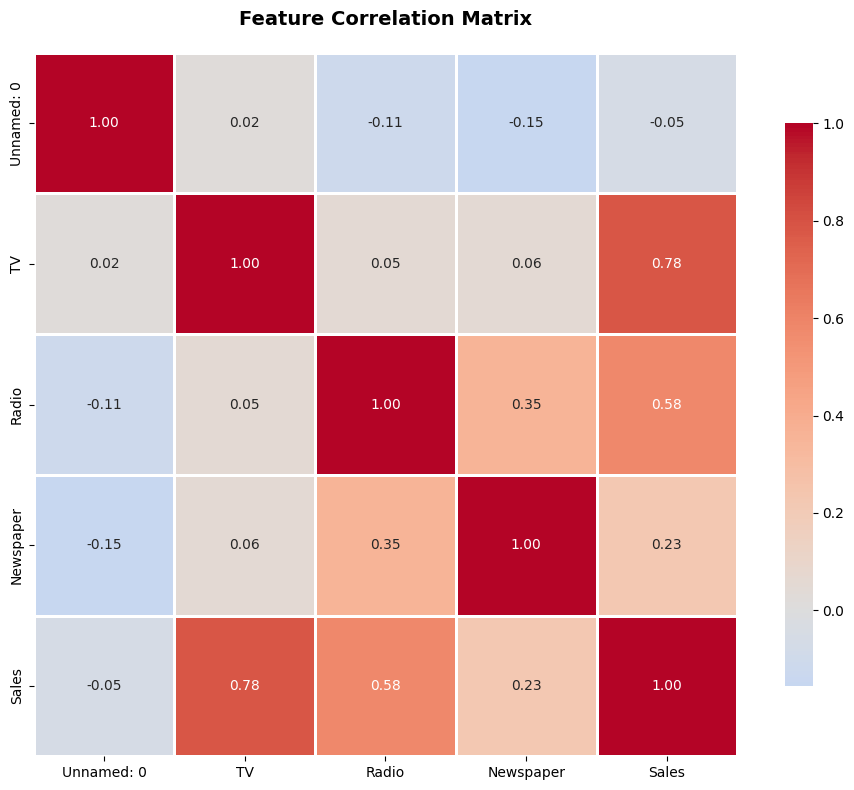


CORRELATION WITH SALES
TV: 0.7822
Radio: 0.5762
Newspaper: 0.2283
Unnamed: 0: -0.0516


In [8]:
if len(numerical_cols) > 0:
    corr_cols = numerical_cols + [sales_column]
    correlation_matrix = df_clean[corr_cols].corr()
    
    plt.figure(figsize=(max(10, len(corr_cols)), max(8, len(corr_cols)*0.8)))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("CORRELATION WITH SALES")
    print("="*70)
    sales_corr = correlation_matrix[sales_column].sort_values(ascending=False)
    for feature, corr in sales_corr.items():
        if feature != sales_column:
            print(f"{feature}: {corr:.4f}")

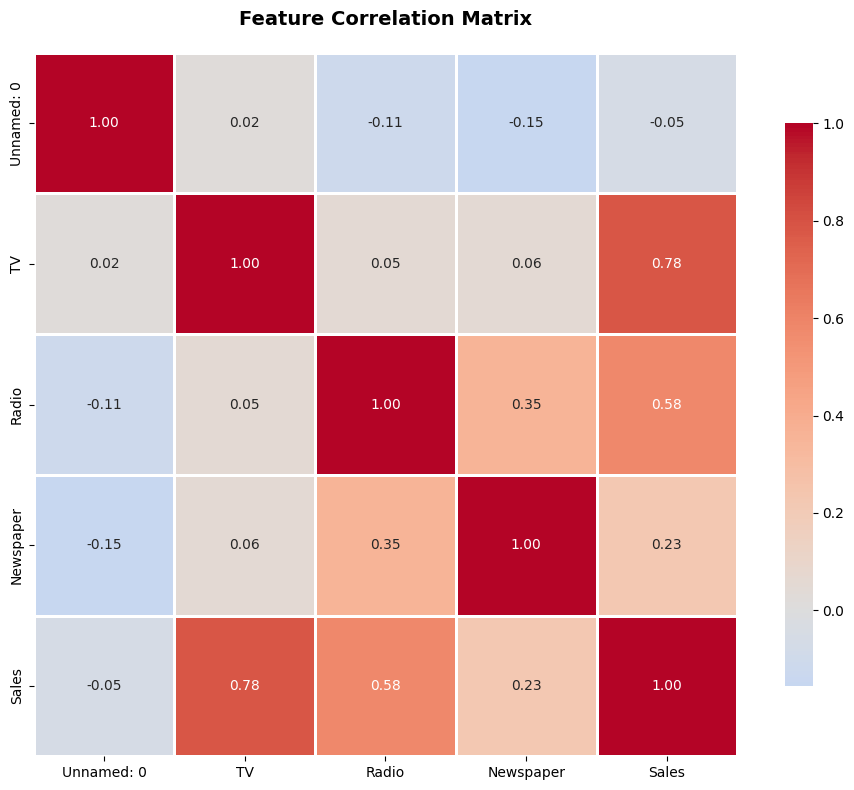


CORRELATION WITH SALES
TV: 0.7822
Radio: 0.5762
Newspaper: 0.2283
Unnamed: 0: -0.0516


In [9]:
if len(numerical_cols) > 0:
    corr_cols = numerical_cols + [sales_column]
    correlation_matrix = df_clean[corr_cols].corr()
    
    plt.figure(figsize=(max(10, len(corr_cols)), max(8, len(corr_cols)*0.8)))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("CORRELATION WITH SALES")
    print("="*70)
    sales_corr = correlation_matrix[sales_column].sort_values(ascending=False)
    for feature, corr in sales_corr.items():
        if feature != sales_column:
            print(f"{feature}: {corr:.4f}")

In [17]:
if len(categorical_cols) > 0:
    n_cat = min(3, len(categorical_cols))
    fig, axes = plt.subplots(1, n_cat, figsize=(6*n_cat, 5))
    
    if n_cat == 1:
        axes = [axes]
    
    for idx in range(n_cat):
        cat_col = categorical_cols[idx]
        
        top_cats = df_clean[cat_col].value_counts().head(10).index
        filtered = df_clean[df_clean[cat_col].isin(top_cats)]
        
        cat_avg = filtered.groupby(cat_col)[sales_column].mean().sort_values(ascending=False)
        
        axes[idx].barh(cat_avg.index, cat_avg.values, 
                      color='#2ecc71', edgecolor='black', linewidth=1.5)
        axes[idx].set_title(f'Average Sales by {cat_col}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Average Sales ($)', fontsize=10)
        axes[idx].grid(alpha=0.3, axis='x')
    for i, v in enumerate(cat_avg.values):
        axes[idx].text(v + max(cat_avg.values)*0.01, i, f'${v:,.0f}', 
                      va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [19]:
df_model = df_clean.copy()

label_encoders = {}

print("="*70)
print("ENCODING CATEGORICAL VARIABLES")
print("="*70)

for col in categorical_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        print(f"✓ Encoded {col}: {len(le.classes_)} unique categories")

print(f"\n✓ Total categorical variables encoded: {len(label_encoders)}")


ENCODING CATEGORICAL VARIABLES

✓ Total categorical variables encoded: 0


In [20]:
X = df_model.drop(columns=[sales_column])
y = df_model[sales_column]

print("="*70)
print("FEATURE AND TARGET PREPARATION")
print("="*70)
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures included: {X.columns.tolist()}")
print(f"\nTarget variable: {sales_column}")
print(f"  Min: ${y.min():,.2f}")
print(f"  Max: ${y.max():,.2f}")
print(f"  Mean: ${y.mean():,.2f}")
print(f"  Median: ${y.median():,.2f}")

FEATURE AND TARGET PREPARATION
Feature matrix shape: (200, 5)
Target vector shape: (200,)

Features included: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Total_Budget']

Target variable: Sales
  Min: $1.60
  Max: $27.00
  Mean: $14.02
  Median: $12.90


In [21]:
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42
)

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"Training set: {X_train.shape[0]} samples ({(1-test_size)*100:.0f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({test_size*100:.0f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled successfully!")
print(f"Scaled training data mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training data std: {X_train_scaled.std():.6f}")


TRAIN-TEST SPLIT
Training set: 160 samples (80%)
Testing set: 40 samples (20%)

✓ Features scaled successfully!
Scaled training data mean: -0.000000
Scaled training data std: 1.000000


In [22]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10),
    'Lasso Regression': Lasso(alpha=10),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

model_results = {}

print("="*70)
print("TRAINING SALES PREDICTION MODELS")
print("="*70)

for model_name, model in models.items():
    print(f"\n{'─'*70}")
    print(f"Training: {model_name}")
    print(f"{'─'*70}")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    model_results[model_name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'rmse': test_rmse,
        'mae': test_mae,
        'predictions': y_pred_test
    }
    
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²: {test_r2:.4f}")
    print(f"RMSE: ${test_rmse:,.2f}")
    print(f"MAE: ${test_mae:,.2f}")
    
    mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
    print(f"MAPE: {mape:.2f}%")

TRAINING SALES PREDICTION MODELS

──────────────────────────────────────────────────────────────────────
Training: Linear Regression
──────────────────────────────────────────────────────────────────────
Training R²: 0.8958
Testing R²: 0.8986
RMSE: $1.79
MAE: $1.47
MAPE: 15.23%

──────────────────────────────────────────────────────────────────────
Training: Ridge Regression
──────────────────────────────────────────────────────────────────────
Training R²: 0.8943
Testing R²: 0.8938
RMSE: $1.83
MAE: $1.50
MAPE: 15.22%

──────────────────────────────────────────────────────────────────────
Training: Lasso Regression
──────────────────────────────────────────────────────────────────────
Training R²: 0.0000
Testing R²: -0.0048
RMSE: $5.63
MAE: $4.96
MAPE: 44.43%

──────────────────────────────────────────────────────────────────────
Training: Decision Tree
──────────────────────────────────────────────────────────────────────
Training R²: 1.0000
Testing R²: 0.9547
RMSE: $1.20
MAE: $0.93
M

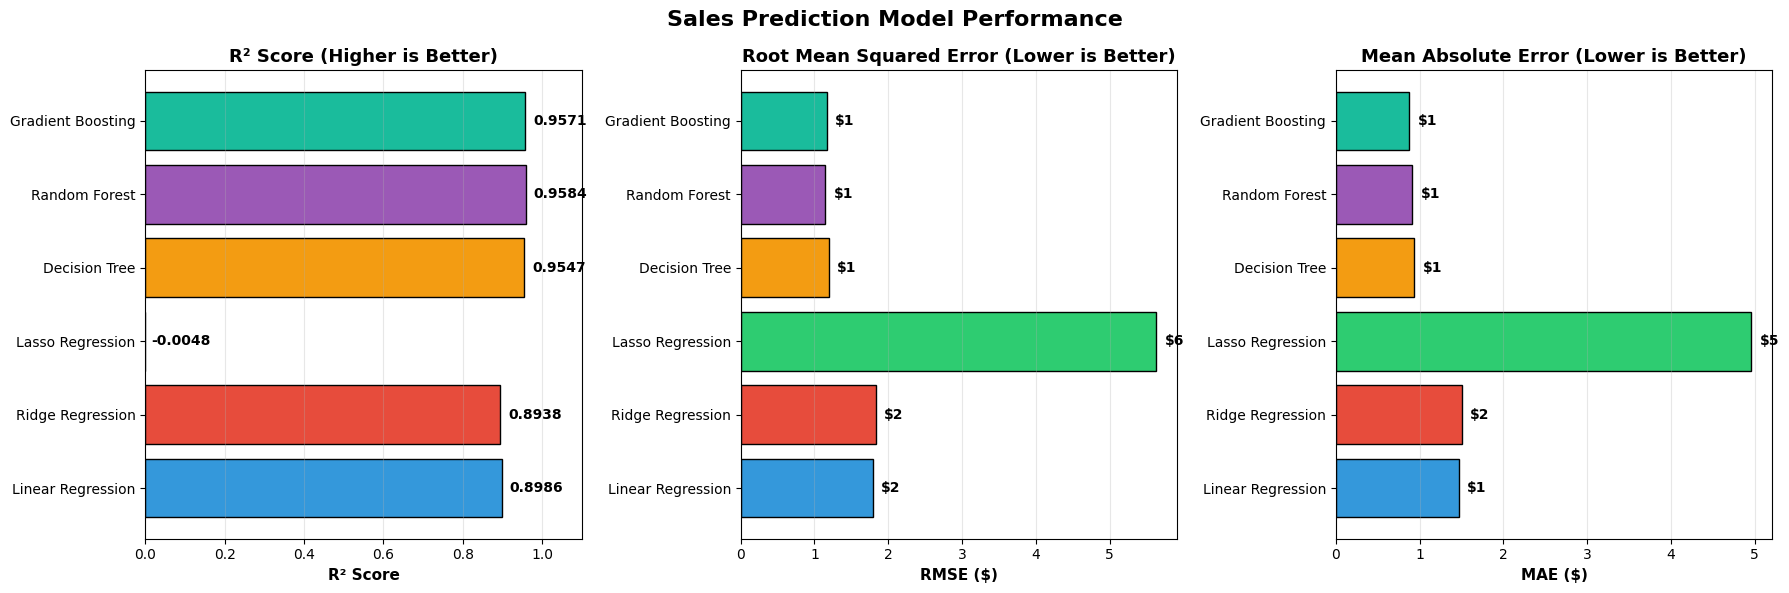

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Sales Prediction Model Performance', fontsize=16, fontweight='bold')

model_names = list(model_results.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

test_r2_scores = [model_results[name]['test_r2'] for name in model_names]

bars = axes[0].barh(model_names, test_r2_scores, color=colors[:len(model_names)], 
                    edgecolor='black')
for i, (bar, score) in enumerate(zip(bars, test_r2_scores)):
    axes[0].text(score + 0.02, i, f'{score:.4f}', 
                va='center', fontweight='bold', fontsize=10)

axes[0].set_xlabel('R² Score', fontsize=11, fontweight='bold')
axes[0].set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1.1)
axes[0].grid(alpha=0.3, axis='x')

rmse_scores = [model_results[name]['rmse'] for name in model_names]

bars = axes[1].barh(model_names, rmse_scores, color=colors[:len(model_names)], 
                    edgecolor='black')
for i, (bar, score) in enumerate(zip(bars, rmse_scores)):
    axes[1].text(score + max(rmse_scores)*0.02, i, f'${score:,.0f}', 
                va='center', fontweight='bold', fontsize=10)

axes[1].set_xlabel('RMSE ($)', fontsize=11, fontweight='bold')
axes[1].set_title('Root Mean Squared Error (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

mae_scores = [model_results[name]['mae'] for name in model_names]

bars = axes[2].barh(model_names, mae_scores, color=colors[:len(model_names)], 
                    edgecolor='black')
for i, (bar, score) in enumerate(zip(bars, mae_scores)):
    axes[2].text(score + max(mae_scores)*0.02, i, f'${score:,.0f}', 
                va='center', fontweight='bold', fontsize=10)

axes[2].set_xlabel('MAE ($)', fontsize=11, fontweight='bold')
axes[2].set_title('Mean Absolute Error (Lower is Better)', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()



🏆 BEST MODEL: Random Forest
R² Score: 0.9584
RMSE: $1.15
MAE: $0.91

This model explains 95.84% of the variance in sales.
On average, predictions are off by $0.91


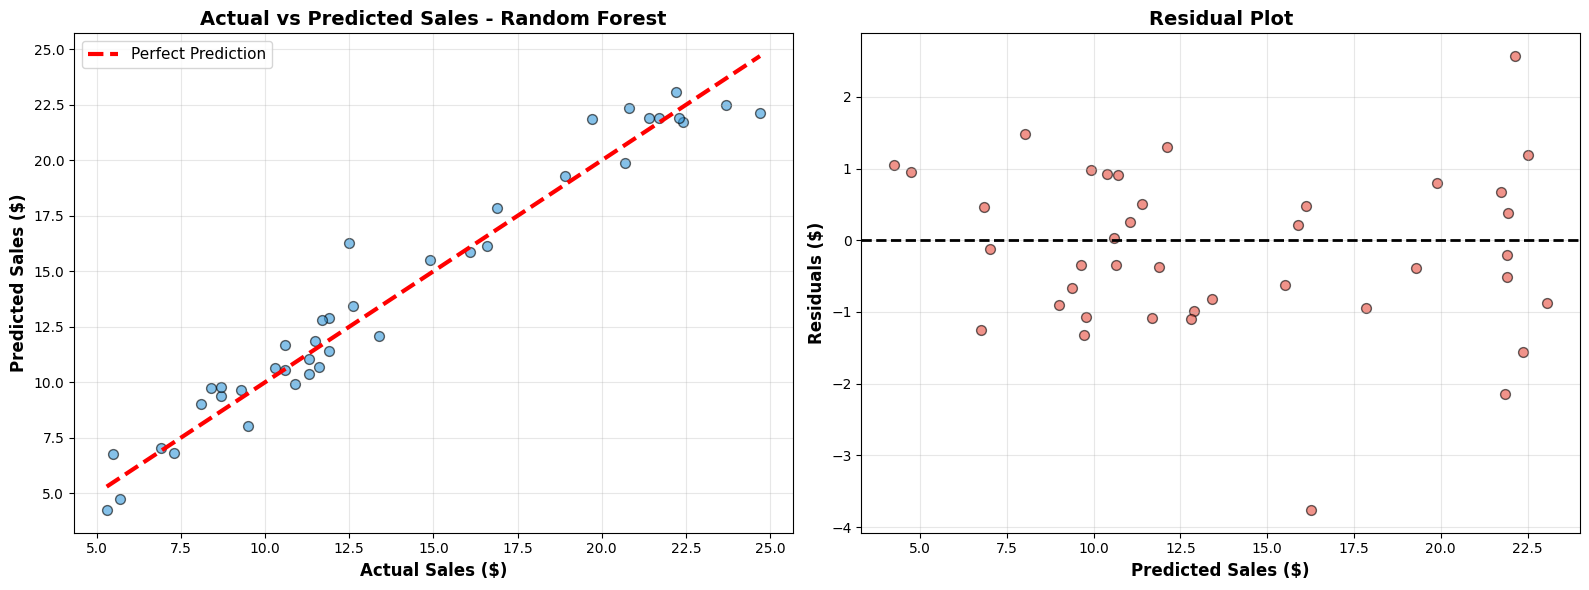

In [24]:
best_model_name = max(model_results, key=lambda x: model_results[x]['test_r2'])
best_model_info = model_results[best_model_name]

print("\n" + "="*70)
print(f"🏆 BEST MODEL: {best_model_name}")
print("="*70)
print(f"R² Score: {best_model_info['test_r2']:.4f}")
print(f"RMSE: ${best_model_info['rmse']:,.2f}")
print(f"MAE: ${best_model_info['mae']:,.2f}")
print(f"\nThis model explains {best_model_info['test_r2']*100:.2f}% of the variance in sales.")
print(f"On average, predictions are off by ${best_model_info['mae']:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, best_model_info['predictions'], 
               alpha=0.6, s=50, color='#3498db', edgecolor='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=3, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Sales ($)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Actual vs Predicted Sales - {best_model_name}', 
                 fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

residuals = y_test - best_model_info['predictions']
axes[1].scatter(best_model_info['predictions'], residuals, 
               alpha=0.6, s=50, color='#e74c3c', edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Sales ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

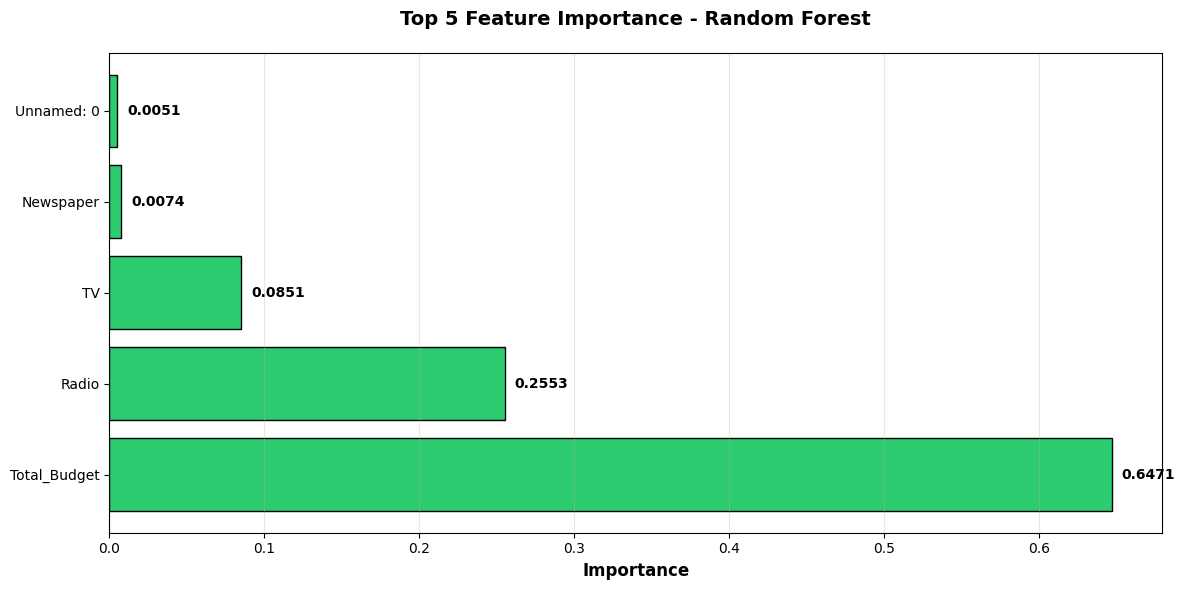


TOP 5 MOST IMPORTANT FEATURES
Total_Budget: 0.6471
Radio: 0.2553
TV: 0.0851
Newspaper: 0.0074
Unnamed: 0: 0.0051


In [25]:
if best_model_name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model_info['model'].feature_importances_
    }).sort_values('Importance', ascending=False)
    
    top_n = min(15, len(feature_importance))
    top_features = feature_importance.head(top_n)
    
    plt.figure(figsize=(12, max(6, top_n*0.4)))
    bars = plt.barh(top_features['Feature'], top_features['Importance'], 
                    color='#2ecc71', edgecolor='black')
    
    for i, (bar, val) in enumerate(zip(bars, top_features['Importance'])):
        plt.text(val + max(top_features['Importance'])*0.01, i, f'{val:.4f}', 
                va='center', fontweight='bold')
    
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f'Top {top_n} Feature Importance - {best_model_name}', 
             fontsize=14, fontweight='bold', pad=20)
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print(f"TOP {top_n} MOST IMPORTANT FEATURES")
    print("="*70)
    for idx, row in top_features.iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")


In [26]:
if len(budget_cols) > 0:
    print("\n" + "="*70)
    print("RETURN ON INVESTMENT (ROI) ANALYSIS")
    print("="*70)
    
    for budget_col in budget_cols:
        correlation = df_clean[[budget_col, sales_column]].corr().iloc[0, 1]
        
        avg_budget = df_clean[budget_col].mean()
        avg_sales = df_clean[sales_column].mean()
        roi = (avg_sales / avg_budget) if avg_budget > 0 else 0
        
        print(f"\n{budget_col}:")
        print(f"  Average Budget: ${avg_budget:,.2f}")
        print(f"  Correlation with Sales: {correlation:.4f}")
        print(f"  Estimated ROI: {roi:.2f}x")
        print(f"  (For every $1 spent, approximately ${roi:.2f} in sales)")


RETURN ON INVESTMENT (ROI) ANALYSIS

TV:
  Average Budget: $147.04
  Correlation with Sales: 0.7822
  Estimated ROI: 0.10x
  (For every $1 spent, approximately $0.10 in sales)

Radio:
  Average Budget: $23.26
  Correlation with Sales: 0.5762
  Estimated ROI: 0.60x
  (For every $1 spent, approximately $0.60 in sales)

Newspaper:
  Average Budget: $30.55
  Correlation with Sales: 0.2283
  Estimated ROI: 0.46x
  (For every $1 spent, approximately $0.46 in sales)


In [27]:
print("\n" + "="*70)
print("SALES PREDICTION ON NEW DATA")
print("="*70)

print("\nTo predict sales for new campaigns, prepare data in this format:")
print(f"Required columns: {X.columns.tolist()}")

sample_indices = np.random.choice(len(X_test), size=min(5, len(X_test)), replace=False)
sample_data = X_test.iloc[sample_indices].copy()
sample_actuals = y_test.iloc[sample_indices]

sample_scaled = scaler.transform(sample_data)
sample_predictions = best_model_info['model'].predict(sample_scaled)

print("\n" + "─"*70)
print("SAMPLE PREDICTIONS")
print("─"*70)

for i in range(len(sample_indices)):
    print(f"\nSample {i+1}:")
    
    for col in X.columns[:min(5, len(X.columns))]:
        if col in label_encoders:
            decoded_value = label_encoders[col].inverse_transform([int(sample_data.iloc[i][col])])[0]
            print(f"  {col}: {decoded_value}")
        else:
            print(f"  {col}: {sample_data.iloc[i][col]:.2f}")
    
    print(f"  Actual Sales: ${sample_actuals.iloc[i]:,.2f}")
    print(f"  Predicted Sales: ${sample_predictions[i]:,.2f}")
    print(f"  Difference: ${abs(sample_actuals.iloc[i] - sample_predictions[i]):,.2f}")
    print(f"  Error: {abs(sample_actuals.iloc[i] - sample_predictions[i])/sample_actuals.iloc[i]*100:.2f}%")
    
    if len(budget_cols) > 0 and len(budget_cols) <= 5:
        total_budget = sum([sample_data.iloc[i][col] for col in budget_cols if col in sample_data.columns])
        if total_budget > 0:
            predicted_roi = sample_predictions[i] / total_budget
            print(f"  Predicted ROI: {predicted_roi:.2f}x")



SALES PREDICTION ON NEW DATA

To predict sales for new campaigns, prepare data in this format:
Required columns: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Total_Budget']

──────────────────────────────────────────────────────────────────────
SAMPLE PREDICTIONS
──────────────────────────────────────────────────────────────────────

Sample 1:
  Unnamed: 0: 171.00
  TV: 50.00
  Radio: 11.60
  Newspaper: 18.40
  Total_Budget: 80.00
  Actual Sales: $8.40
  Predicted Sales: $9.73
  Difference: $1.33
  Error: 15.81%
  Predicted ROI: 0.12x

Sample 2:
  Unnamed: 0: 151.00
  TV: 280.70
  Radio: 13.90
  Newspaper: 37.00
  Total_Budget: 331.60
  Actual Sales: $16.10
  Predicted Sales: $15.89
  Difference: $0.21
  Error: 1.32%
  Predicted ROI: 0.05x

Sample 3:
  Unnamed: 0: 10.00
  TV: 199.80
  Radio: 2.60
  Newspaper: 21.20
  Total_Budget: 223.60
  Actual Sales: $10.60
  Predicted Sales: $11.69
  Difference: $1.09
  Error: 10.25%
  Predicted ROI: 0.05x

Sample 4:
  Unnamed: 0: 68.00
  TV: 139.3

In [28]:
import pickle
import json

model_filename = f'best_sales_model_{best_model_name.replace(" ", "_").lower()}.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_info['model'], file)

scaler_filename = 'sales_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

encoders_filename = 'sales_label_encoders.pkl'
with open(encoders_filename, 'wb') as file:
    pickle.dump(label_encoders, file)

print(f"\n✓ Model saved as: {model_filename}")
print(f"✓ Scaler saved as: {scaler_filename}")
print(f"✓ Encoders saved as: {encoders_filename}")

metadata = {
    'feature_columns': X.columns.tolist(),
    'model_name': best_model_name,
    'test_r2': float(best_model_info['test_r2']),
    'test_rmse': float(best_model_info['rmse']),
    'test_mae': float(best_model_info['mae'])
}

with open('sales_model_metadata.json', 'w') as file:
    json.dump(metadata, file, indent=4)

print(f"✓ Metadata saved as: sales_model_metadata.json")


✓ Model saved as: best_sales_model_random_forest.pkl
✓ Scaler saved as: sales_scaler.pkl
✓ Encoders saved as: sales_label_encoders.pkl
✓ Metadata saved as: sales_model_metadata.json
